In [3]:
import sys
import os
sys.path.append(os.path.abspath(os.path.join('..')))

In [4]:
import importlib.util

In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from model_2026_04_26 import ProblemSolvingModel

In [13]:
def get_global_p(model):
    x = np.array([a.x for a in model.agents], dtype=float)
    return x.mean()

def get_agent_ps(model):
    x = np.array([a.x for a in model.agents], dtype=float)
    return x.mean(axis=1)

def run_model_collect(model_kwargs, steps=None):
    model = ProblemSolvingModel(**model_kwargs)
    T = model.R if steps is None else steps
    
    rows = []
    rows.append({
        "step": 0,
        "p": get_global_p(model),
        "homogeneity": model.homogeneity,
        "avg_violations": model.avg_true_V,
        "min_violations": model.min_true_V,
        "comm_scale": model.comm_scale,
        "kb_capacity": model.kb_capacity,
        "M": model.M
    })
    
    for _ in range(T):
        model.step()
        rows.append({
            "step": model.steps,
            "p": get_global_p(model),
            "homogeneity": model.homogeneity,
            "avg_violations": model.avg_true_V,
            "min_violations": model.min_true_V,
            "comm_scale": model.comm_scale,
            "kb_capacity": model.kb_capacity,
            "M": model.M
        })
    
    return model, pd.DataFrame(rows)

In [38]:
base_params = dict(
    N=100,
    K=30,
    alpha=4,
    obs_prob=0.1,
    R=3000,
    type_network="Random",
    connect_prob=0.1,
    kb_fraction=1,
    local_obs_fraction=1,
    run_mode="basic",
    seed=1
)

model, df = run_model_collect(base_params)
df.head()

,step,p,homogeneity,avg_violations,min_violations,comm_scale,kb_capacity,M
0,0,0.507333,0.530667,72.34,56,0.199554,120,120
1,1,0.508333,0.531000,72.20,56,0.199554,120,120
2,2,0.509333,0.532667,71.97,56,0.199554,120,120
3,3,0.511000,0.535667,71.53,56,0.199554,120,120
4,4,0.517000,0.540333,70.69,56,0.199554,120,120


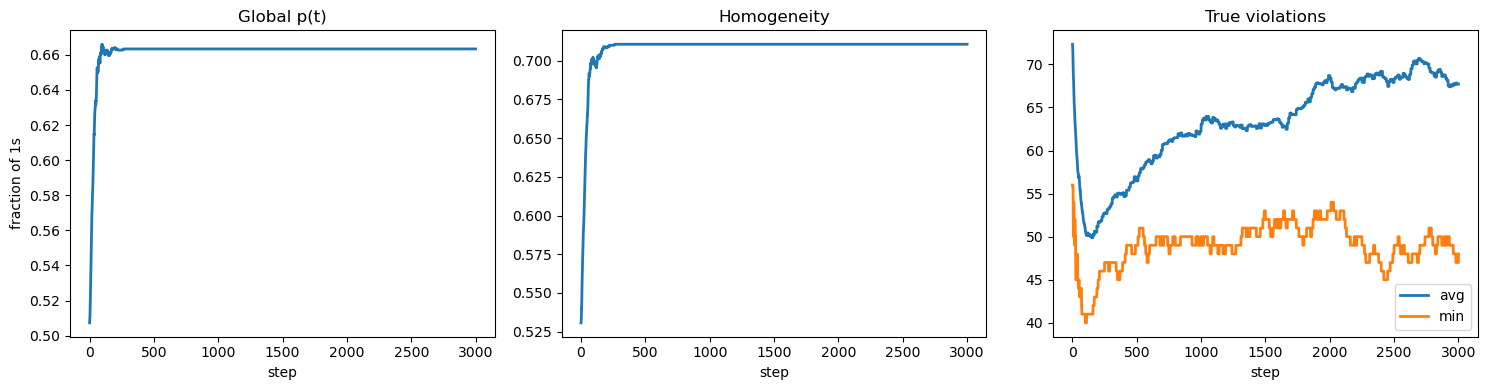

In [39]:
fig, ax = plt.subplots(1, 3, figsize=(15, 4))

ax[0].plot(df["step"], df["p"], lw=2)
ax[0].set_title("Global p(t)")
ax[0].set_xlabel("step")
ax[0].set_ylabel("fraction of 1s")

ax[1].plot(df["step"], df["homogeneity"], lw=2)
ax[1].set_title("Homogeneity")
ax[1].set_xlabel("step")

ax[2].plot(df["step"], df["avg_violations"], label="avg", lw=2)
ax[2].plot(df["step"], df["min_violations"], label="min", lw=2)
ax[2].set_title("True violations")
ax[2].set_xlabel("step")
ax[2].legend()

plt.tight_layout()
plt.show()

In [40]:
fit_df = df[(df["p"] > 0) & (df["p"] < 0.999)].copy()
fit_df["log1mp"] = np.log(1 - fit_df["p"])

coef = np.polyfit(fit_df["step"], fit_df["log1mp"], 1)
slope, intercept = coef
c_est = -slope
p0_est = 1 - np.exp(intercept)

print("Estimated c =", c_est)
print("Implied p0   =", p0_est)

Estimated c = 8.086309573192002e-06
Implied p0   = 0.6578177221159103


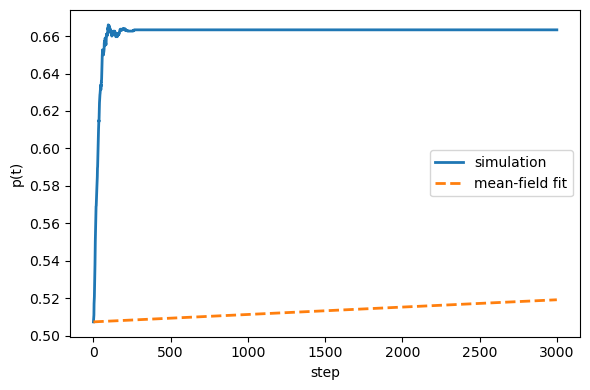

In [41]:
df["p_mf_fit"] = 1 - (1 - df["p"].iloc[0]) * np.exp(-c_est * df["step"])

plt.figure(figsize=(6,4))
plt.plot(df["step"], df["p"], label="simulation", lw=2)
plt.plot(df["step"], df["p_mf_fit"], "--", label="mean-field fit", lw=2)
plt.xlabel("step")
plt.ylabel("p(t)")
plt.legend()
plt.tight_layout()
plt.show()

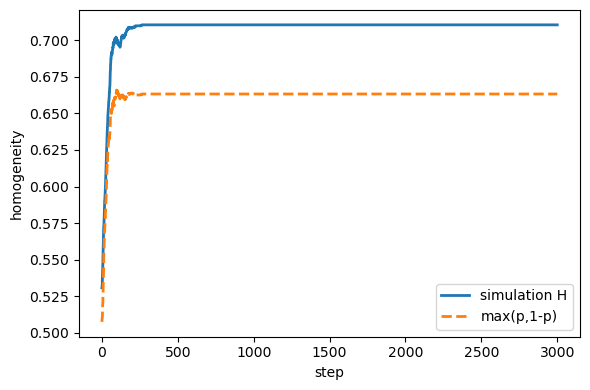

In [42]:
df["H_mf"] = np.maximum(df["p"], 1 - df["p"])
df["H_error"] = df["homogeneity"] - df["H_mf"]

plt.figure(figsize=(6,4))
plt.plot(df["step"], df["homogeneity"], label="simulation H", lw=2)
plt.plot(df["step"], df["H_mf"], "--", label="max(p,1-p)", lw=2)
plt.xlabel("step")
plt.ylabel("homogeneity")
plt.legend()
plt.tight_layout()
plt.show()

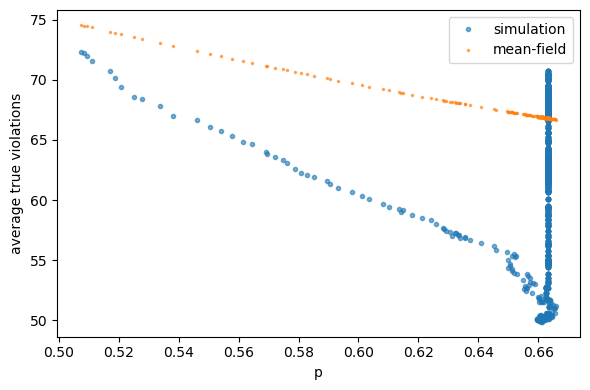

In [43]:
M = model.M
df["V_mf"] = M * (1 - df["p"] + 0.5 * df["p"]**2)

plt.figure(figsize=(6,4))
plt.plot(df["p"], df["avg_violations"], "o", ms=3, alpha=0.6, label="simulation")
plt.plot(df["p"], df["V_mf"], ".", ms=3, alpha=0.6, label="mean-field")
plt.xlabel("p")
plt.ylabel("average true violations")
plt.legend()
plt.tight_layout()
plt.show()

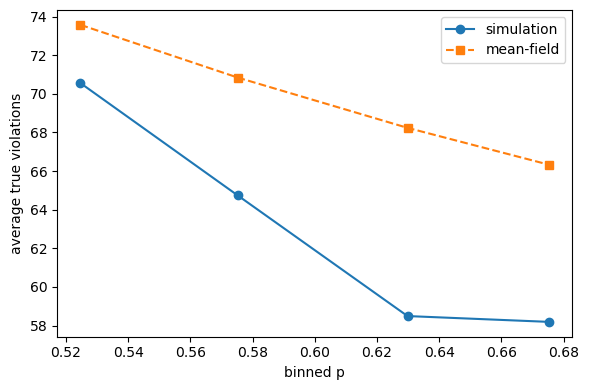

In [21]:
tmp = df.copy()
tmp["p_bin"] = pd.cut(tmp["p"], bins=np.linspace(0, 1, 21), include_lowest=True)
binned = tmp.groupby("p_bin", observed=False).agg(
    p_mean=("p", "mean"),
    V_sim=("avg_violations", "mean"),
    V_mf=("V_mf", "mean"),
    n=("p", "size")
).dropna()

plt.figure(figsize=(6,4))
plt.plot(binned["p_mean"], binned["V_sim"], "o-", label="simulation")
plt.plot(binned["p_mean"], binned["V_mf"], "s--", label="mean-field")
plt.xlabel("binned p")
plt.ylabel("average true violations")
plt.legend()
plt.tight_layout()
plt.show()

In [44]:
from collections import Counter

clause_counts = Counter(op for op, vars_ in model.C)
clause_counts, model.M

(Counter({'XOR': 66, 'AND': 54}), 120)

p = 0.6633333333333334
model.homogeneity = 0.7106666666666667
H_exact from fj = 0.7106666666666668
0.5 + <|fj-0.5|> = 0.7106666666666667


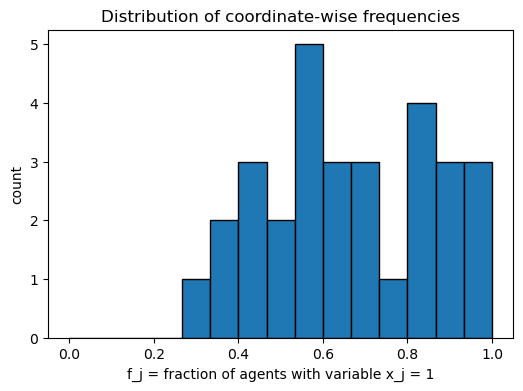

In [46]:
def bit_frequencies(model):
    x = np.array([a.x for a in model.agents], dtype=float)
    return x.mean(axis=0)

fj = bit_frequencies(model)
p_emp = fj.mean()
H_exact = np.mean(np.maximum(fj, 1 - fj))
H_alt = 0.5 + np.mean(np.abs(fj - 0.5))

print("p =", p_emp)
print("model.homogeneity =", model.homogeneity)
print("H_exact from fj =", H_exact)
print("0.5 + <|fj-0.5|> =", H_alt)

plt.figure(figsize=(6,4))
plt.hist(fj, bins=np.linspace(0,1,16), edgecolor='k')
plt.xlabel("f_j = fraction of agents with variable x_j = 1")
plt.ylabel("count")
plt.title("Distribution of coordinate-wise frequencies")
plt.show()

In [47]:
def clause_pair_stats(model):
    and_vals = []
    xor_vals = []
    
    for a in model.agents:
        x = a.x
        for op, (i, j) in model.C:
            xi, xj = x[i-1], x[j-1]
            if op == "AND":
                and_vals.append((xi, xj))
            elif op == "XOR":
                xor_vals.append((xi, xj))
    
    and_vals = np.array(and_vals)
    xor_vals = np.array(xor_vals)
    
    out = {}
    
    if len(and_vals):
        out["q11_AND_actual"] = np.mean((and_vals[:,0] == 1) & (and_vals[:,1] == 1))
        out["AND_violation_actual"] = np.mean(~((and_vals[:,0] == 1) & (and_vals[:,1] == 1)))
    else:
        out["q11_AND_actual"] = np.nan
        out["AND_violation_actual"] = np.nan
    
    if len(xor_vals):
        out["qeq_XOR_actual"] = np.mean(xor_vals[:,0] == xor_vals[:,1])
        out["XOR_violation_actual"] = np.mean(xor_vals[:,0] == xor_vals[:,1])
    else:
        out["qeq_XOR_actual"] = np.nan
        out["XOR_violation_actual"] = np.nan
    
    p = get_global_p(model)
    out["p"] = p
    out["q11_factorized"] = p**2
    out["qeq_factorized"] = p**2 + (1-p)**2
    out["AND_violation_factorized"] = 1 - p**2
    out["XOR_violation_factorized"] = p**2 + (1-p)**2
    
    return pd.Series(out)

pair_stats = clause_pair_stats(model)
pair_stats

q11_AND_actual              0.399815
AND_violation_actual        0.600185
qeq_XOR_actual              0.534848
XOR_violation_actual        0.534848
p                           0.663333
q11_factorized              0.440011
qeq_factorized              0.553356
AND_violation_factorized    0.559989
XOR_violation_factorized    0.553356
dtype: float64

In [48]:
def predicted_V_pair(model):
    stats = clause_pair_stats(model)
    n_and = sum(1 for op, _ in model.C if op == "AND")
    n_xor = sum(1 for op, _ in model.C if op == "XOR")
    
    V_pair = (
        n_and * stats["AND_violation_actual"] +
        n_xor * stats["XOR_violation_actual"]
    )
    
    V_scalar = (
        n_and * (1 - stats["p"]**2) +
        n_xor * (stats["p"]**2 + (1 - stats["p"])**2)
    )
    
    return pd.Series({
        "V_sim_actual": model.avg_true_V,
        "V_pair_from_actual_pairs": V_pair,
        "V_scalar_factorized": V_scalar
    })

predicted_V_pair(model)

V_sim_actual                67.710000
V_pair_from_actual_pairs    67.710000
V_scalar_factorized         66.760867
dtype: float64

In [ ]:
def estimate_c_from_df(df):
    fit_df = df[(df["p"] > 0) & (df["p"] < 0.999)].copy()
    if len(fit_df) < 3:
        return np.nan
    slope, intercept = np.polyfit(fit_df["step"], np.log(1 - fit_df["p"]), 1)
    return -slope

network_specs = [
    dict(type_network="Random", connect_prob=0.1),
    dict(type_network="Small World", n_size=4, rewire_prob=0.1),
    dict(type_network="Scale Fr]ee", min_deg=2),
    dict(type_network="Hierarchical", nlayers=3, intra_layer_connectance=0.5, inter_layer_connectance=0.1),
]

rows = []
for i, spec in enumerate(network_specs):
    params = base_params.copy()
    params.update(spec)
    params["seed"] = 10
    
    model_i, df_i = run_model_collect(params)
    rows.append({
        "network": spec["type_network"],
        "final_p": df_i["p"].iloc[-1],
        "final_H": df_i["homogeneity"].iloc[-1],
        "final_avgV": df_i["avg_violations"].iloc[-1],
        "c_est": estimate_c_from_df(df_i),
        "comm_scale": model_i.comm_scale
    })

net_summary = pd.DataFrame(rows)
net_summary

,network,final_p,final_H,final_avgV,c_est,comm_scale
0,Random,0.666333,0.753000,65.27,0.000015,0.203569
1,Small World,0.671333,0.768000,58.36,0.000021,0.263249
2,Scale Free,0.677000,0.756333,68.30,0.000058,1.040144
3,Hierarchical,0.673333,0.814667,66.46,0.000016,0.086577


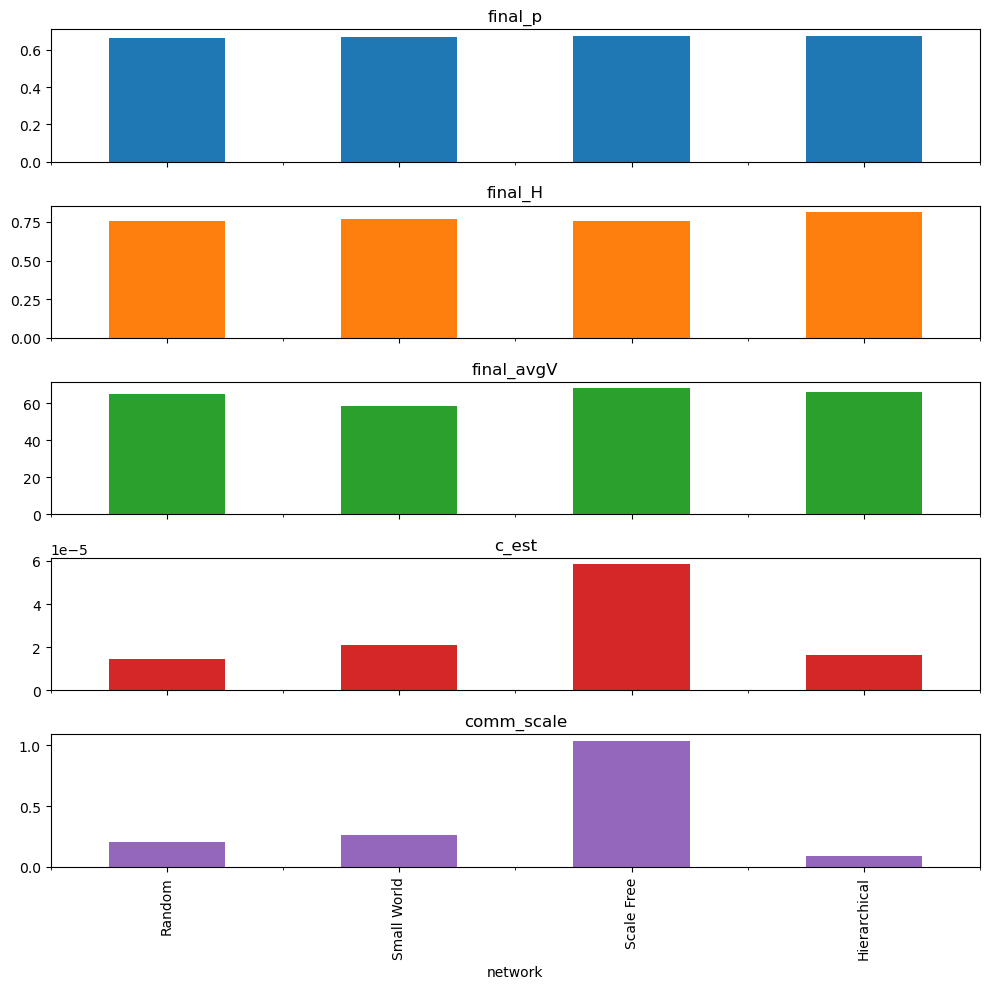

In [23]:
net_summary.set_index("network")[["final_p", "final_H", "final_avgV", "c_est", "comm_scale"]].plot(
    kind="bar", subplots=True, figsize=(10, 10), legend=False, layout=(5,1)
)
plt.tight_layout()
plt.show()